**source**=https://www.kaggle.com/competitions/bike-sharing-demand/data?select=train.csv

The dataset comes from the Kaggle Bike Sharing Demand competition.

In [62]:
import kagglehub
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
df=pd.read_csv(r"C:\Users\victus\Downloads\bike-sharing-demand\train.csv")

In [2]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
df.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [5]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
season,10886.0,2.506614,1.116174,1.00,2.0000,3.000,4.0000,4.0000
holiday,10886.0,0.028569,0.166599,0.00,0.0000,0.000,0.0000,1.0000
workingday,10886.0,0.680875,0.466159,0.00,0.0000,1.000,1.0000,1.0000
weather,10886.0,1.418427,0.633839,1.00,1.0000,1.000,2.0000,4.0000
temp,10886.0,20.230860,7.791590,0.82,13.9400,20.500,26.2400,41.0000
atemp,10886.0,23.655084,8.474601,0.76,16.6650,24.240,31.0600,45.4550
humidity,10886.0,61.886460,19.245033,0.00,47.0000,62.000,77.0000,100.0000
windspeed,10886.0,12.799395,8.164537,0.00,7.0015,12.998,16.9979,56.9969
casual,10886.0,36.021955,49.960477,0.00,4.0000,17.000,49.0000,367.0000
registered,10886.0,155.552177,151.039033,0.00,36.0000,118.000,222.0000,886.0000


In [7]:
df.shape

(10886, 12)

In [8]:
print(df.columns.tolist())

['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']


# check misssing values

In [9]:
missing = df.isnull().sum()

In [10]:
missing

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

In [11]:
missing_percentage = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

print(missing_percentage)

datetime      0.0
season        0.0
holiday       0.0
workingday    0.0
weather       0.0
temp          0.0
atemp         0.0
humidity      0.0
windspeed     0.0
casual        0.0
registered    0.0
count         0.0
dtype: float64


# check duplicate record

In [12]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [13]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [14]:
print(df["datetime"].dtype)

datetime64[ns]


In [15]:
print(df["count"].describe())

count    10886.000000
mean       191.574132
std        181.144454
min          1.000000
25%         42.000000
50%        145.000000
75%        284.000000
max        977.000000
Name: count, dtype: float64


In [16]:
df["count"].value_counts()

count
5      169
4      149
3      144
6      135
2      132
      ... 
819      1
830      1
825      1
688      1
636      1
Name: count, Length: 822, dtype: int64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(8)
memory usage: 1020.7 KB


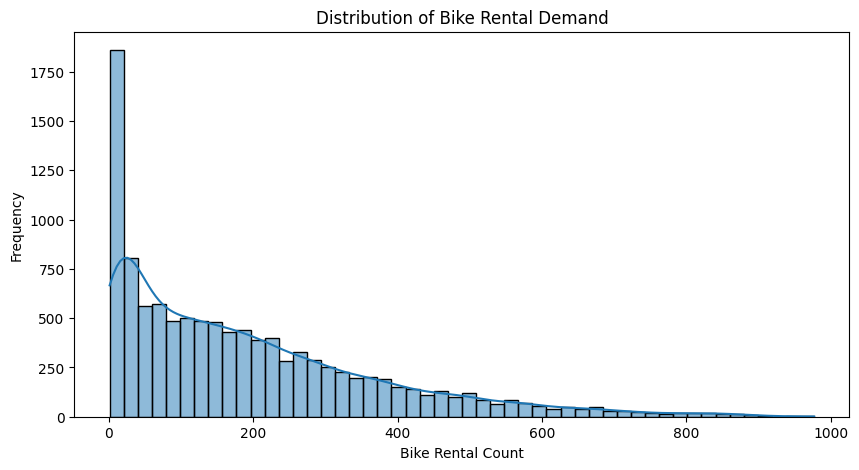

In [18]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Bike Rental Demand")
plt.xlabel("Bike Rental Count")
plt.ylabel("Frequency")

plt.show()

- the target is highly right skewed

# feature engineering with datetime column

In [19]:
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour


In [20]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4


# eda visualization of different columns 

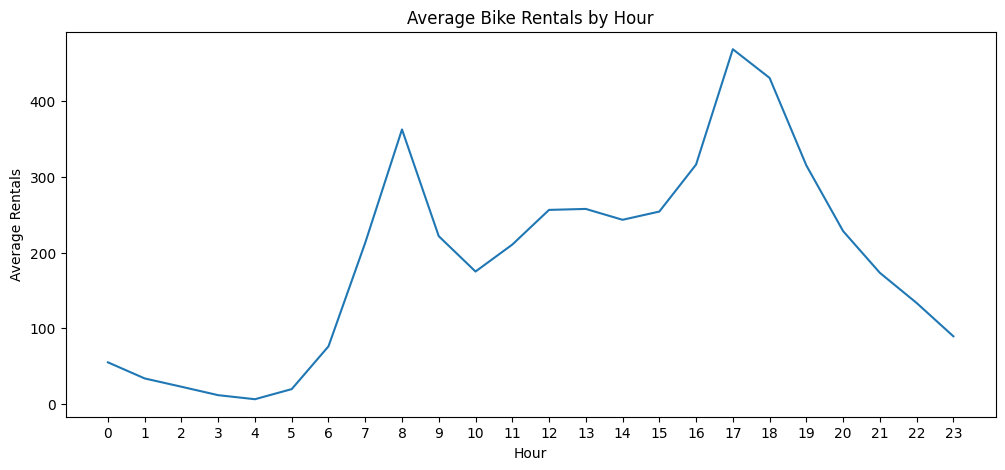

In [21]:
hourly = df.groupby("hour")["count"].mean()

plt.figure(figsize=(12, 5))

hourly.plot()

plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Rentals")

plt.xticks(range(24))

plt.show()

- we can se that the bike rented more on morning and evening time

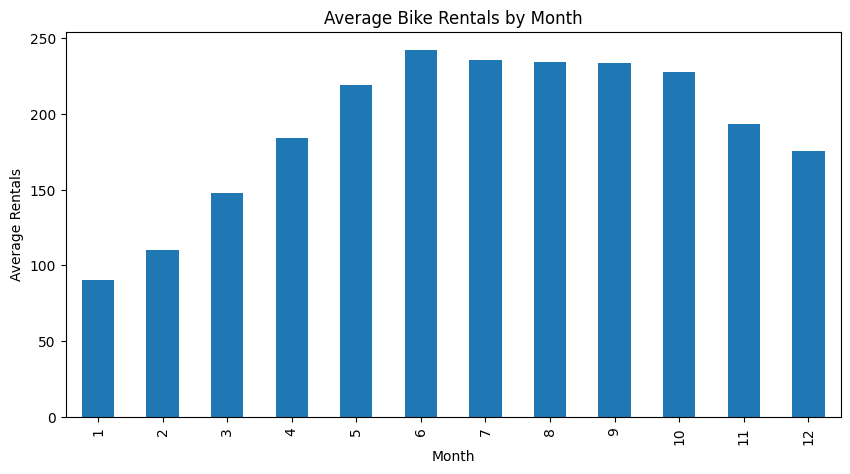

In [22]:
monthly = df.groupby("month")["count"].mean()

plt.figure(figsize=(10, 5))

monthly.plot(kind="bar")

plt.title("Average Bike Rentals by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")

plt.show()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: count, dtype: float64


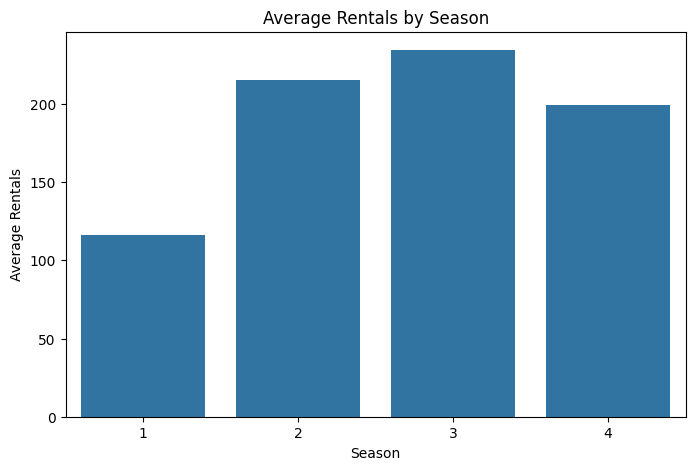

In [23]:
season_avg = df.groupby("season")["count"].mean()

print(season_avg)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_avg.index,
    y=season_avg.values
)

plt.title("Average Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")

plt.show()

- season 2 and 3 have more bike rental
- season 2 =summer and season 3=fall

In [24]:
df["season"].value_counts()

season
4    2734
2    2733
3    2733
1    2686
Name: count, dtype: int64

In [25]:
df["weather"].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64


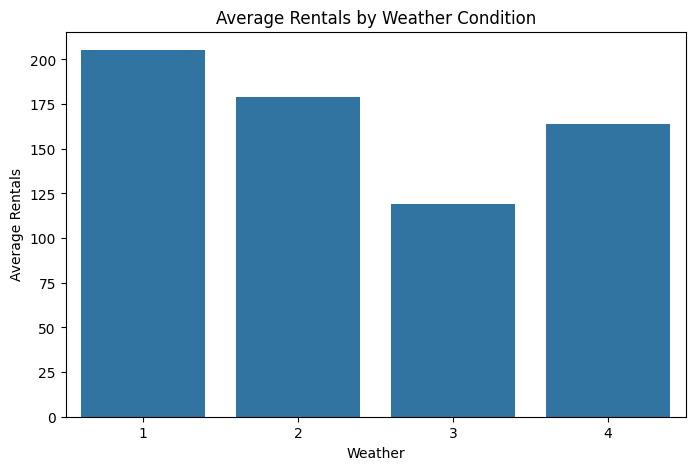

In [26]:
weather_avg = df.groupby("weather")["count"].mean()

print(weather_avg)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=weather_avg.index,
    y=weather_avg.values
)

plt.title("Average Rentals by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Rentals")

plt.show()

- weather 1 has more rental means generally a good weather has high demand of rental
- weather:
1: Clear, Few clouds, Partly cloudy, Partly cloudy
2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog 

workingday
0    188.506621
1    193.011873
Name: count, dtype: float64


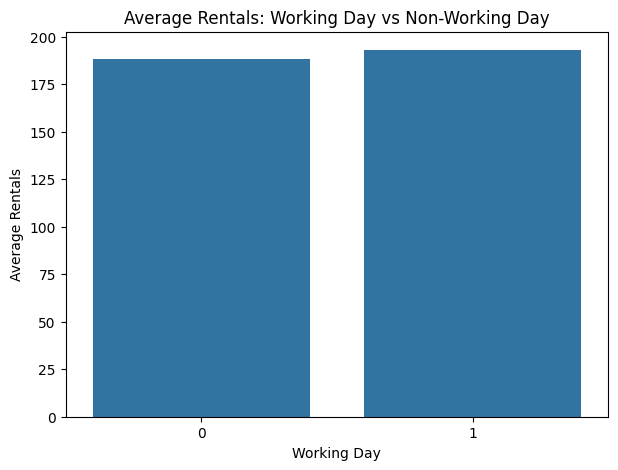

In [27]:
workingday_avg = df.groupby("workingday")["count"].mean()

print(workingday_avg)
plt.figure(figsize=(7, 5))

sns.barplot(
    x=workingday_avg.index,
    y=workingday_avg.values
)

plt.title("Average Rentals: Working Day vs Non-Working Day")

plt.xlabel("Working Day")
plt.ylabel("Average Rentals")

plt.show()

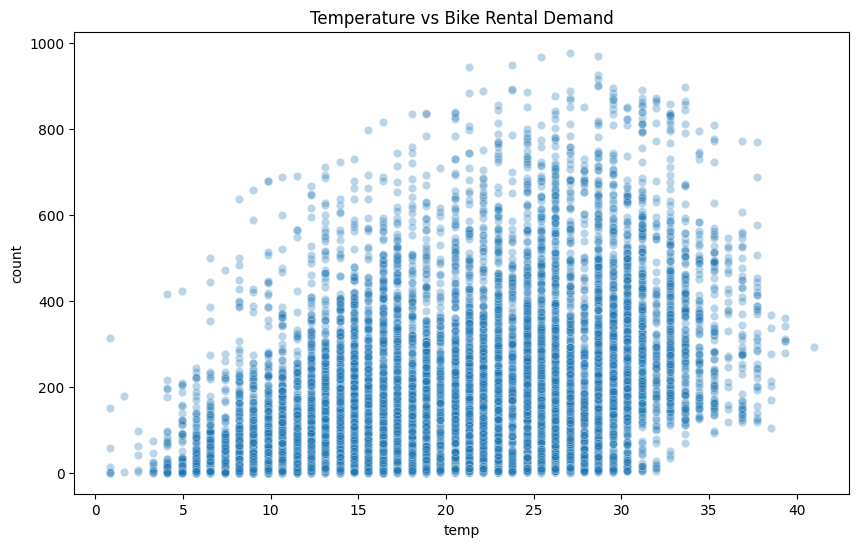

In [28]:
 plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temp",
    y="count",
    alpha=0.3
)

plt.title("Temperature vs Bike Rental Demand")

plt.show()

- a normal day temperature has high demand as we can see from 20 to 30 theres a high demand of bike

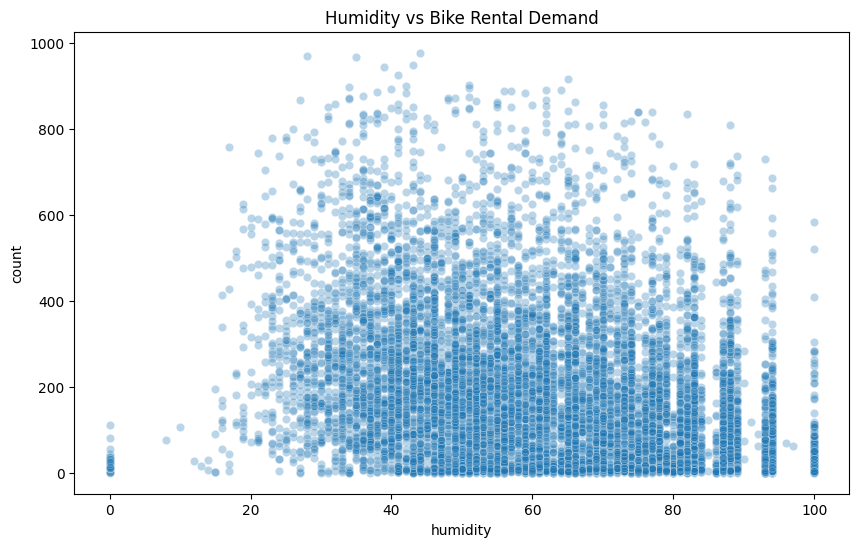

In [29]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="humidity",
    y="count",
    alpha=0.3
)

plt.title("Humidity vs Bike Rental Demand")

plt.show()

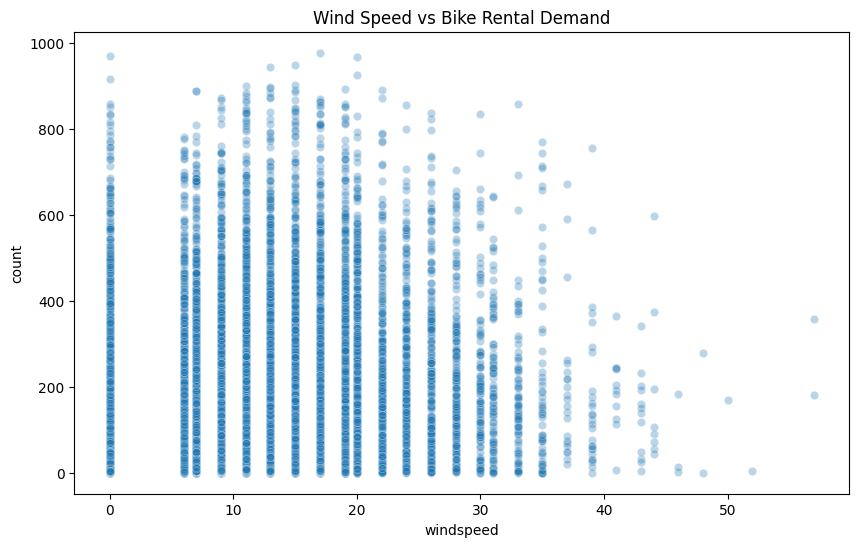

In [30]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="windspeed",
    y="count",
    alpha=0.3
)

plt.title("Wind Speed vs Bike Rental Demand")

plt.show()

- the lesser the wind speed the higher the demand 

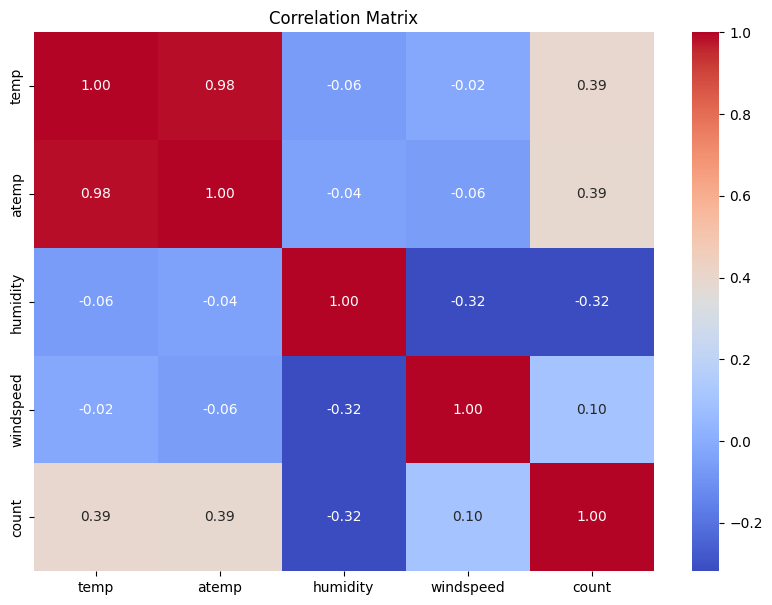

In [31]:
numeric_cols = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "count"
]

plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

- temp and atemp are correlated with demand and temp ↔ atemp will usually have strong correlation because atemp represents perceived temperature.
  

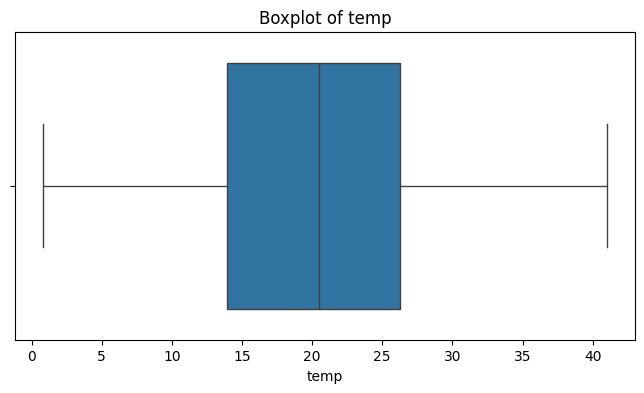

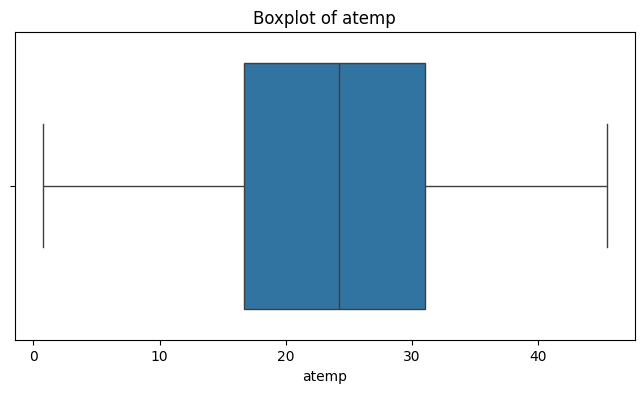

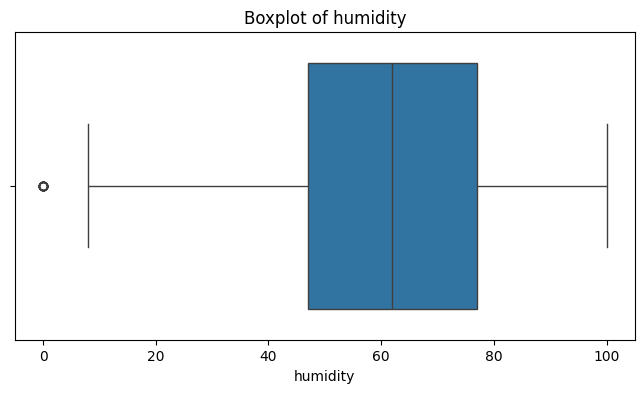

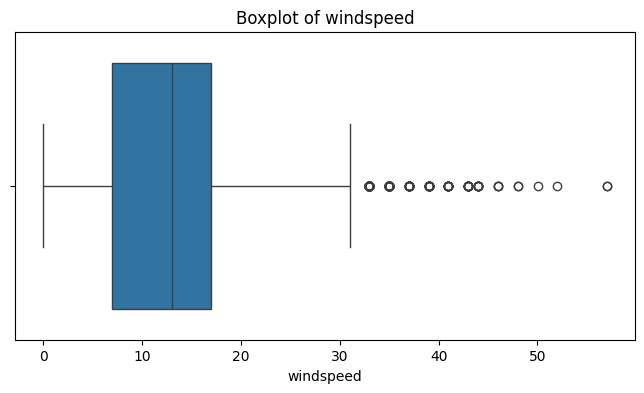

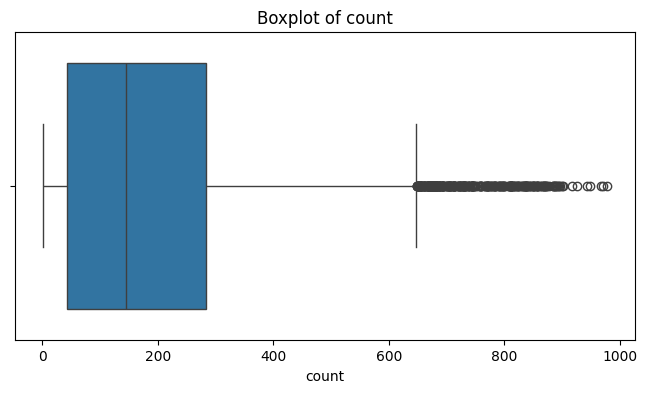

In [32]:
numeric_features = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "count"
]

for column in numeric_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.show()

In [33]:
for column in ["season", "holiday", "workingday", "weather"]:

    print("\n", column)

    print(df[column].value_counts().sort_index())


 season
season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64

 holiday
holiday
0    10575
1      311
Name: count, dtype: int64

 workingday
workingday
0    3474
1    7412
Name: count, dtype: int64

 weather
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


In [34]:
print("Negative temperature:", (df["temp"] < 0).sum())
print("Negative humidity:", (df["humidity"] < 0).sum())
print("Negative windspeed:", (df["windspeed"] < 0).sum())
print("Negative count:", (df["count"] < 0).sum())

Negative temperature: 0
Negative humidity: 0
Negative windspeed: 0
Negative count: 0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
dtypes: datetime64[ns](1), 

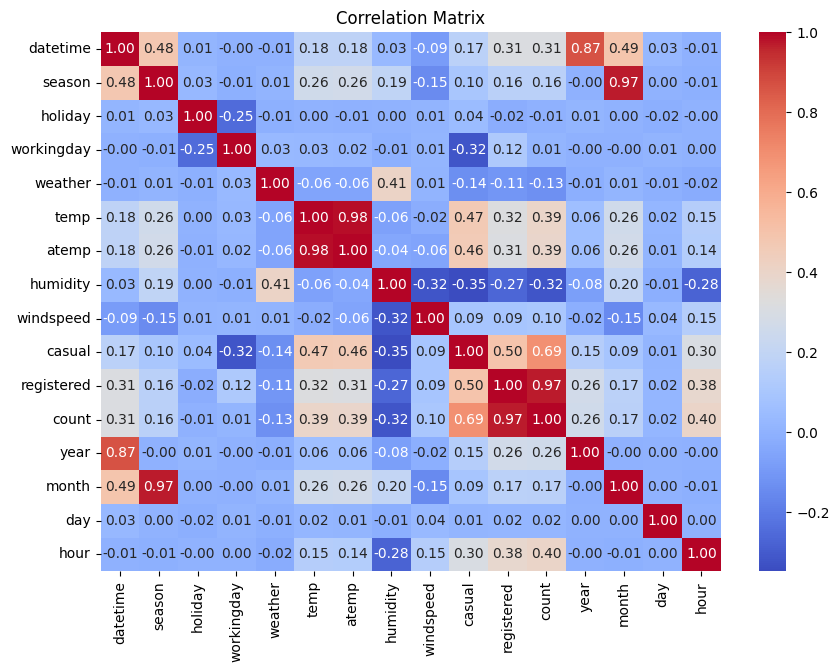

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [37]:
df.head(2)

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1


In [38]:
df=df.drop(columns=['datetime','casual','registered'])

In [39]:
df.head(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,16,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,40,2011,1,1,1


In [40]:
x=df.drop(columns=["count"])
y=df["count"]

In [41]:
x.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,year,month,day,hour
0,1,0,0,1,9.84,14.395,81,0.0,2011,1,1,0
1,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,1
2,1,0,0,1,9.02,13.635,80,0.0,2011,1,1,2
3,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,3
4,1,0,0,1,9.84,14.395,75,0.0,2011,1,1,4


In [42]:
y.shape


(10886,)

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [44]:
x_train.shape

(8708, 12)

In [45]:
x_test.shape


(2178, 12)

In [46]:
y_train.shape

(8708,)

# scaled the data


In [47]:
from sklearn.preprocessing import StandardScaler

In [48]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)

In [49]:
x_test_scaled=scaler.transform(x_test)

# experiment 1 using decision tree

In [50]:
dr=DecisionTreeRegressor(random_state=42,max_depth=10,min_samples_leaf=5)

In [51]:
dr.fit(x_train_scaled,y_train)

DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=42)

In [52]:
dr.score(x_test_scaled,y_test)*100

90.30474099212003

In [53]:
dr.score(x_train_scaled,y_train)*100

93.06353113203781

# experiment 2 using random forest

In [54]:
rf = RandomForestRegressor(n_estimators=100,random_state=42, n_jobs=-1)

In [55]:
rf.fit(x_train_scaled,y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [56]:
rf.score(x_test_scaled,y_test)*100

94.53639431774047

In [57]:
rf.score(x_train_scaled,y_train)*100

99.19567754255382

# experiment 3 using gradient boost

In [58]:
gb = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=7,
    random_state=42
)
gb.fit(x_train_scaled, y_train)

print("Train:", gb.score(x_train_scaled, y_train)*100)
print("Test: ", gb.score(x_test_scaled, y_test)*100)

Train: 99.3053021242778
Test:  95.40915253224817


# experiment 4 using xgb regressor

In [59]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
xgb.fit(x_train_scaled, y_train)

print("Train:", xgb.score(x_train_scaled, y_train)*100)
print("Test: ", xgb.score(x_test_scaled, y_test)*100)

Train: 98.16879034042358
Test:  95.56357264518738


In [60]:

preds = gb.predict(x_test_scaled)

mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)                          # or mean_squared_error(y_test, preds, squared=False) in older sklearn
mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R²:   {r2:.3f}")

MSE:  1515.30
RMSE: 38.93
MAE:  25.06
R²:   0.954


R² = 0.954: the model explains 95.4% of the variance in bike counts. Excellent for this dataset.
RMSE = 38.93: on average, predictions are off by about 39 bikes/hour (weighted more by larger errors).
MAE = 25.06: the typical error is about 25 bikes/hour (a more "typical" error, less swayed by outliers).

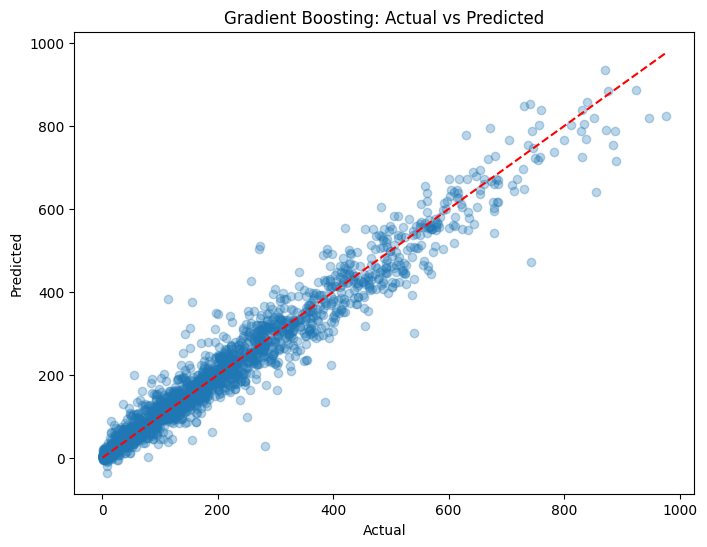

In [61]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.show()

In [63]:

os.makedirs("model", exist_ok=True)

# Save trained Gradient Boosting model
joblib.dump(
    gb,
    "model/gradient_boosting_model.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "model/scaler.pkl"
)

# Save feature order
joblib.dump(
    x.columns.tolist(),
    "model/feature_order.pkl"
)

print("Model and preprocessing files saved successfully!")

Model and preprocessing files saved successfully!
